<a href="https://colab.research.google.com/github/Nancy727/women-safety/blob/main/WomenSafetyMl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Model loaded successfully
🧠 Last Model Accuracy: MAE=280.38, R²=0.993

Available States: A & N ISLANDS, A & N Islands, ANDHRA PRADESH, ARUNACHAL PRADESH, ASSAM, Andhra Pradesh, Arunachal Pradesh, Assam, BIHAR, Bihar, CHANDIGARH, CHHATTISGARH, Chandigarh, Chhattisgarh, D & N HAVELI, D&N Haveli, DAMAN & DIU, Daman & Diu, Delhi UT, GOA, GUJARAT, Goa, Gujarat, HARYANA, HIMACHAL PRADESH, Haryana, Himachal Pradesh, JAMMU & KASHMIR, JHARKHAND, Jammu & Kashmir, Jharkhand, KARNATAKA, KERALA, Karnataka, Kerala, LAKSHADWEEP, Lakshadweep, MADHYA PRADESH, MAHARASHTRA, MANIPUR, MEGHALAYA, MIZORAM, Madhya Pradesh, Maharashtra, Manipur, Meghalaya, Mizoram, NAGALAND, Nagaland, ODISHA, Odisha, PUDUCHERRY, PUNJAB, Puducherry, Punjab, RAJASTHAN, Rajasthan, SIKKIM, Sikkim, TAMIL NADU, TRIPURA, Tamil Nadu, Telangana, Tripura, UTTAR PRADESH, UTTARAKHAND, Uttar Pradesh, Uttarakhand, WEST BENGAL, West Bengal

~~~~~~~~~~~~~ WOMEN SAFETY ANALYTICS DASHBOARD ~~~~~~~~~~~~~

Enter State Name: Bihar


<ipython-input-37-83ab4f1ec6a5>:142: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


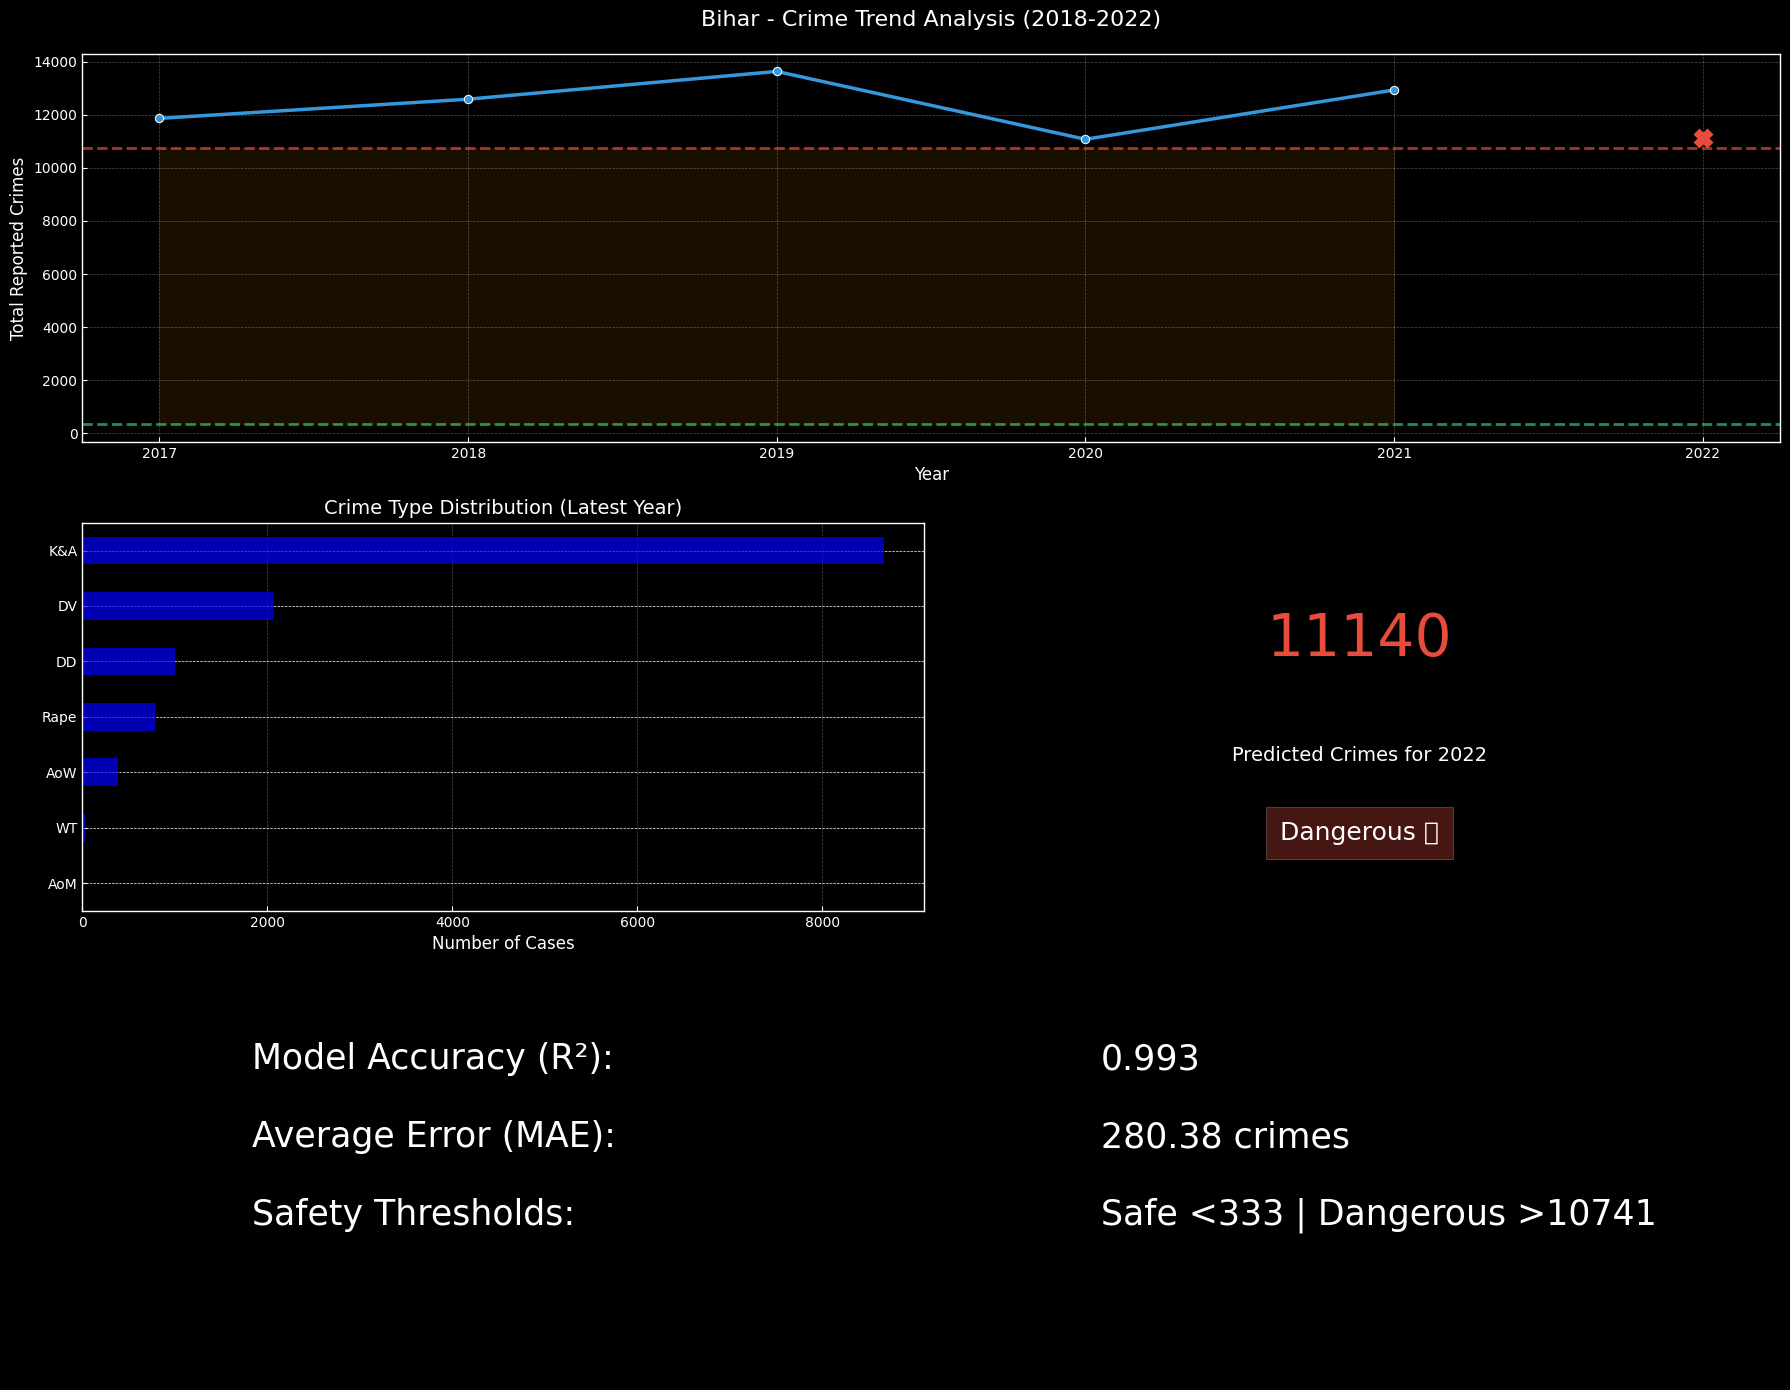


🔍 Safety Analysis for Bihar:
- Last 5 years trend: [np.int64(11866), np.int64(12589), np.int64(13635), np.int64(11078), np.int64(12936)]
- Prediction for 2022: 11140 crimes (Dangerous 🔴)
- Model confidence: 99.3% accuracy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
from matplotlib.ticker import FuncFormatter

# ================== 1. DATA LOADING & SETUP ==================
# Set visual style
plt.style.use('dark_background')


palette = {'Safe 🟢': '#2ecc71', 'Moderate 🟡': '#f39c12', 'Dangerous 🔴': '#e74c3c'}

# Load data
data = pd.read_csv("/content/CrimesOnWomenData.csv")
crime_columns = ['Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV', 'WT']
data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# ================== 2. DYNAMIC SAFETY THRESHOLDS ==================
def calculate_thresholds(df):
    latest_year = df['Year'].max()
    latest_data = df[df['Year'] == latest_year]['Total_Crimes']
    return {
        'safe': latest_data.quantile(0.33),
        'danger': latest_data.quantile(0.66)
    }

thresholds = calculate_thresholds(data)

def classify_safety(total_crimes):
    if total_crimes < thresholds['safe']: return "Safe 🟢"
    elif total_crimes < thresholds['danger']: return "Moderate 🟡"
    else: return "Dangerous 🔴"

# ================== 3. MODEL TRAINING WITH ACCURACY TRACKING ==================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Year'] + crime_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['State'])
])

X = data[['State', 'Year'] + crime_columns]
y = data['Total_Crimes']

try:
    model = joblib.load('crime_model.joblib')
    preprocessor = joblib.load('preprocessor.joblib')
    accuracy_metrics = joblib.load('accuracy_metrics.joblib')
    print("✓ Model loaded successfully")
    print(f"🧠 Last Model Accuracy: MAE={accuracy_metrics['MAE']}, R²={accuracy_metrics['R²']}")
except:
    print("⚙️ Training new model...")
    X_processed = preprocessor.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=200,
                                max_depth=15,
                                min_samples_leaf=2,
                                random_state=42)
    model.fit(X_train, y_train)

    # Calculate accuracy metrics
    y_pred = model.predict(X_test)
    accuracy_metrics = {
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'R²': round(r2_score(y_test, y_pred), 3)
    }
    print(f"✅ Model trained (MAE: {accuracy_metrics['MAE']}, R²: {accuracy_metrics['R²']})")

    # Save all components
    joblib.dump(model, 'crime_model.joblib')
    joblib.dump(preprocessor, 'preprocessor.joblib')
    joblib.dump(accuracy_metrics, 'accuracy_metrics.joblib')

# ================== 4. ENHANCED VISUALIZATION DASHBOARD ==================
def create_dashboard(state, historical, prediction):
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 2)

    # --- MAIN TREND PLOT ---
    ax1 = fig.add_subplot(gs[0, :])
    sns.lineplot(data=historical, x='Year', y='Total_Crimes',
                marker='o', linewidth=2.5, ax=ax1, color='#3498db')

    # Add thresholds and safety zones
    ax1.axhline(thresholds['safe'], color=palette['Safe 🟢'], linestyle='--', alpha=0.7)
    ax1.axhline(thresholds['danger'], color=palette['Dangerous 🔴'], linestyle='--', alpha=0.7)
    ax1.fill_between(historical['Year'], thresholds['safe'], thresholds['danger'],
                    color=palette['Moderate 🟡'], alpha=0.1)

    # Highlight prediction
    pred_year = historical['Year'].max() + 1
    ax1.plot(pred_year, prediction, 'X', markersize=12,
            color=palette[classify_safety(prediction)], markeredgewidth=2)

    ax1.set_title(f'{state} - Crime Trend Analysis (2018-{pred_year})', fontsize=16, pad=20)
    ax1.set_ylabel('Total Reported Crimes', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # --- CRIME COMPOSITION ---
    ax2 = fig.add_subplot(gs[1, 0])
    latest = historical[historical['Year'] == historical['Year'].max()].iloc[0]
    crime_data = latest[crime_columns].sort_values()
    crime_data.plot.barh(ax=ax2, color='blue', alpha=0.7)
    ax2.set_title('Crime Type Distribution (Latest Year)', fontsize=14)
    ax2.set_xlabel('Number of Cases')
    ax2.grid(True, axis='x', alpha=0.3)

    # --- PREDICTION CARD ---
    ax3 = fig.add_subplot(gs[1, 1])
    safety = classify_safety(prediction)
    ax3.set_facecolor('#f8f9fa')
    ax3.text(0.5, 0.7, f"{prediction:.0f}",
            ha='center', va='center', fontsize=42,
            color=palette[safety])
    ax3.text(0.5, 0.4, f"Predicted Crimes for {pred_year}",
            ha='center', va='center', fontsize=14)
    ax3.text(0.5, 0.2, safety,
            ha='center', va='center', fontsize=18,
            bbox=dict(facecolor=palette[safety], alpha=0.3, pad=10))
    ax3.axis('off')

    # --- MODEL METRICS ---
    ax4 = fig.add_subplot(gs[2, :])
    metrics = [
        ("Model Accuracy (R²)", accuracy_metrics['R²']),
        ("Average Error (MAE)", f"{accuracy_metrics['MAE']} crimes"),
        ("Safety Thresholds", f"Safe <{thresholds['safe']:.0f} | Dangerous >{thresholds['danger']:.0f}")
    ]

    for i, (label, value) in enumerate(metrics):
        ax4.text(0.1, 0.8-i*0.2, f"{label}:", fontsize=25, ha='left')
        ax4.text(0.6, 0.8-i*0.2, f"{value}", fontsize=25, ha='left', color='white')
                # bbox=dict(facecolor='black', alpha=0.7))

    ax4.axis('off')
    plt.tight_layout()
    plt.show()

# ================== 5. PREDICTION ENGINE ==================
def predict_state_safety():
    print("\n" + "="*60)
    print(" WOMEN SAFETY ANALYTICS DASHBOARD ".center(60, '~'))
    print("="*60)

    state = input("\nEnter State Name: ").strip().title()

    if state not in data['State'].unique():
        print(f"\n⚠️ Available states:\n{', '.join(sorted(data['State'].unique()))}")
        return

    # Get historical data (last 5 years)
    state_data = data[data['State'] == state].sort_values('Year').tail(5)
    latest_year = state_data['Year'].max()

    # Prepare prediction input (using 3-year moving average)
    avg_crimes = state_data[crime_columns].mean()
    prediction_input = pd.DataFrame([{
        'State': state,
        'Year': latest_year + 1,
        **{col: avg_crimes[col] for col in crime_columns}
    }])

    # Make prediction
    processed_input = preprocessor.transform(prediction_input)
    predicted_crimes = model.predict(processed_input)[0]

    # Generate dashboard
    create_dashboard(state, state_data, predicted_crimes)

    # Console report
    print(f"\n🔍 Safety Analysis for {state}:")
    print(f"- Last 5 years trend: {list(state_data['Total_Crimes'].values)}")
    print(f"- Prediction for {latest_year + 1}: {predicted_crimes:.0f} crimes ({classify_safety(predicted_crimes)})")
    print(f"- Model confidence: {accuracy_metrics['R²']*100:.1f}% accuracy")

# ================== 6. MAIN EXECUTION ==================
if __name__ == "__main__":
    print("\nAvailable States:", ", ".join(sorted(data['State'].unique())))
    while True:
        predict_state_safety()
        if input("\nAnalyze another state? (y/n): ").lower() != 'y':
            print("\n" + "="*60)
            print(" IMPORTANT: Always report crimes to local authorities ".center(60, '~'))
            print("="*60)
            break